<a href="https://colab.research.google.com/github/g0so/Projects/blob/main/AVD2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import os
import numpy as np
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point, Polygon
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from torchsummary import summary

In [5]:
print("Step 2: Creating synthetic dataset...")

# Define several restricted zones (polygons)
zones = {
    "Airport": Polygon([(-74.0, 40.7), (-74.0, 40.8), (-73.9, 40.8), (-73.9, 40.7)]),
    "GovBuilding": Polygon([(-73.95, 40.75), (-73.95, 40.76), (-73.94, 40.76), (-73.94, 40.75)]),
    "MilitaryBase": Polygon([(-74.1, 40.85), (-74.1, 40.9), (-74.05, 40.9), (-74.05, 40.85)])
}
zones_gdf = gpd.GeoDataFrame(
    {'zone_name': list(zones.keys())},
    geometry=list(zones.values()),
    crs="EPSG:4326"
)
all_zones_multipoly = zones_gdf.unary_union

# --- Generate drone flight paths ---
num_flights = 50
points_per_flight = 100
all_flight_points = []

for i in range(num_flights):
    # Decide if this flight will be a violating one
    is_violating_flight = np.random.rand() > 0.5

    # Generate start and end points
    start_lon = np.random.uniform(-74.2, -73.8)
    start_lat = np.random.uniform(40.6, 41.0)

    if is_violating_flight:
        # Target a point inside one of the zones
        target_zone = np.random.choice(zones_gdf.geometry)
        target_point = target_zone.representative_point()
        end_lon, end_lat = target_point.x, target_point.y
    else:
        # Fly somewhere safe
        end_lon = np.random.uniform(-74.2, -73.8)
        end_lat = np.random.uniform(40.6, 41.0)

    # Create the flight path
    lons = np.linspace(start_lon, end_lon, points_per_flight) + np.random.normal(0, 0.001, points_per_flight)
    lats = np.linspace(start_lat, end_lat, points_per_flight) + np.random.normal(0, 0.001, points_per_flight)

    for j in range(points_per_flight):
        all_flight_points.append({
            'flight_id': i,
            'timestamp': j,
            'longitude': lons[j],
            'latitude': lats[j]
        })

# Create a GeoDataFrame from the points
flights_df = pd.DataFrame(all_flight_points)
flights_gdf = gpd.GeoDataFrame(
    flights_df,
    geometry=gpd.points_from_xy(flights_df.longitude, flights_df.latitude),
    crs="EPSG:4326"
)

# --- Label the data: 1 if inside a zone, 0 otherwise ---
# Use a spatial join to find points inside zones
violations = gpd.sjoin(flights_gdf, zones_gdf, how="inner", predicate='within')
flights_gdf['is_violation'] = 0
flights_gdf.loc[violations.index, 'is_violation'] = 1

print(f"Dataset created with {len(flights_gdf)} points.")
print(f"Total violations found: {flights_gdf['is_violation'].sum()}")

Step 2: Creating synthetic dataset...
Dataset created with 5000 points.
Total violations found: 1257


/tmp/ipython-input-2026384016.py:14: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  all_zones_multipoly = zones_gdf.unary_union



Step 3: Visualising sample data...


/tmp/ipython-input-2040104643.py:29: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend()


Saved data visualization to synthetic_data_visualization.png


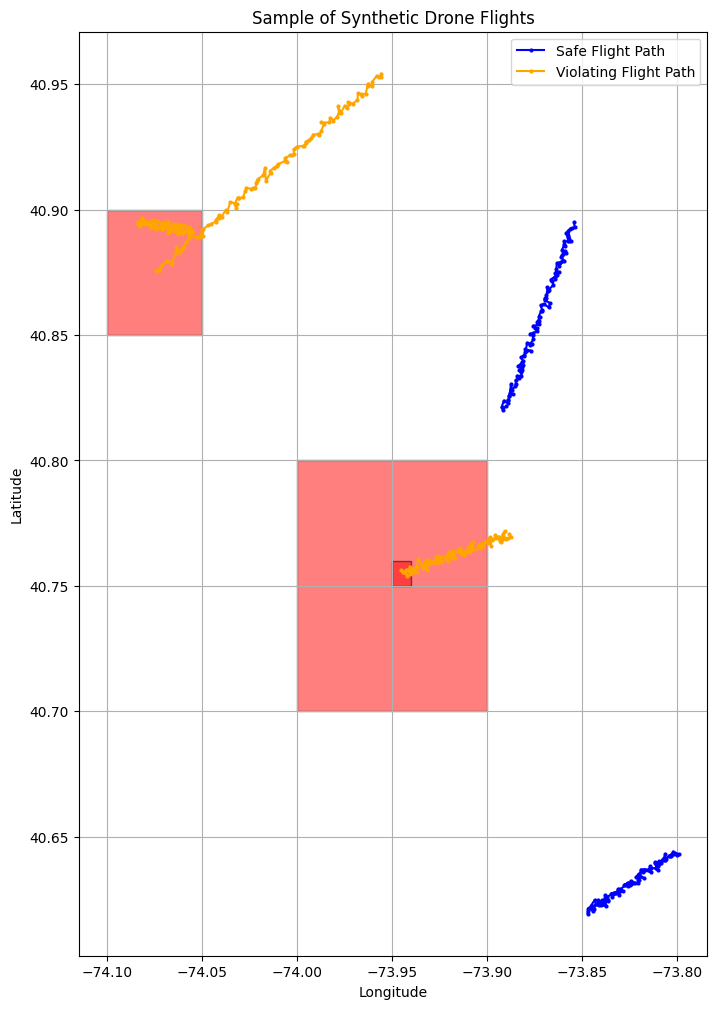

In [6]:
print("\nStep 3: Visualising sample data...")

fig, ax = plt.subplots(1, 1, figsize=(12, 12))
zones_gdf.plot(ax=ax, color='red', alpha=0.5, edgecolor='black', label='Restricted Zones')

# To avoid duplicate labels in the legend, we'll keep track of them manually.
plotted_labels = set()

# Plot a few sample flights to avoid clutter
for flight_id in range(5):
    sample_flight = flights_gdf[flights_gdf['flight_id'] == flight_id]

    # Determine the flight type and its corresponding label/color
    if sample_flight['is_violation'].sum() > 0:
        label, color = 'Violating Flight Path', 'orange'
    else:
        label, color = 'Safe Flight Path', 'blue'

    # Only add the 'label' argument to the plot function the first time we see a new label type.
    if label not in plotted_labels:
        ax.plot(sample_flight.geometry.x, sample_flight.geometry.y, marker='o', markersize=2, linestyle='-', color=color, label=label)
        plotted_labels.add(label)
    else:
        ax.plot(sample_flight.geometry.x, sample_flight.geometry.y, marker='o', markersize=2, linestyle='-', color=color)

ax.set_title('Sample of Synthetic Drone Flights')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.legend()
plt.grid(True)
plt.savefig("synthetic_data_visualization.png")
print("Saved data visualization to synthetic_data_visualization.png")
plt.show()

In [7]:
print("\nStep 4: Loading and preprocessing data...")

# For this model, we'll use simple features: longitude and latitude.
# In a real-world scenario, you would add more features like speed, altitude, heading etc.
features = ['longitude', 'latitude']
target = 'is_violation'

X = flights_gdf[features].values
y = flights_gdf[target].values

# Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Data preprocessing complete.")


Step 4: Loading and preprocessing data...
Data preprocessing complete.


In [8]:
print("\nStep 5: Splitting data into training and testing sets...")

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

# Convert to PyTorch Tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)

# Create DataLoaders
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

print("Data splitting complete.")


Step 5: Splitting data into training and testing sets...
Data splitting complete.


In [9]:
print("\nStep 6: Creating model architecture...")

class ViolationDetector(nn.Module):
    def __init__(self, input_features):
        super(ViolationDetector, self).__init__()
        self.layer_stack = nn.Sequential(
            nn.Linear(input_features, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, 1),
            nn.Sigmoid() # Sigmoid for binary classification probability
        )

    def forward(self, x):
        return self.layer_stack(x)

# Instantiate the model
input_dim = len(features)
model = ViolationDetector(input_features=input_dim)
print("Model created.")


Step 6: Creating model architecture...
Model created.


In [10]:
print("\nStep 7: Training the model...")

# --- Model Summary ---
print("Model Summary:")
# Note: torchsummary needs the model to be on the same device as the input tensor.
# If using GPU, move model to device before calling summary.
device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)
summary(model, input_size=(input_dim,))

# --- Training Setup ---
loss_function = nn.BCELoss() # Binary Cross-Entropy Loss
optimizer = optim.Adam(model.parameters(), lr=0.001)
epochs = 20

# --- Training Loop ---
model.train() # Set model to training mode
for epoch in range(epochs):
    epoch_loss = 0.0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        # Zero the gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(inputs)
        loss = loss_function(outputs, labels)

        # Backward pass and optimization
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    print(f"Epoch {epoch+1}/{epochs}, Loss: {epoch_loss/len(train_loader):.4f}")

print("Model training complete.")

# --- Save the Model ---
MODEL_PATH = "airspace_violation_detector.pth"
torch.save(model.state_dict(), MODEL_PATH)
print(f"Model saved to {MODEL_PATH}")


Step 7: Training the model...
Model Summary:
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1                   [-1, 64]             192
              ReLU-2                   [-1, 64]               0
           Dropout-3                   [-1, 64]               0
            Linear-4                   [-1, 32]           2,080
              ReLU-5                   [-1, 32]               0
           Dropout-6                   [-1, 32]               0
            Linear-7                    [-1, 1]              33
           Sigmoid-8                    [-1, 1]               0
Total params: 2,305
Trainable params: 2,305
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.01
Estimated Total Size (MB): 0.01
----------------------------------------------------------------



Step 8: Evaluating model performance...

Classification Report:
               precision    recall  f1-score   support

     Safe (0)       0.99      0.99      0.99       749
Violation (1)       0.96      0.96      0.96       251

     accuracy                           0.98      1000
    macro avg       0.97      0.97      0.97      1000
 weighted avg       0.98      0.98      0.98      1000

Saved confusion matrix to confusion_matrix.png


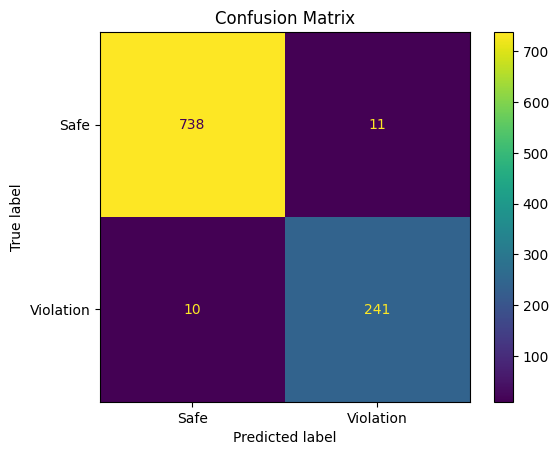

In [12]:
print("\nStep 8: Evaluating model performance...")

model.eval() # Set model to evaluation mode
with torch.no_grad():
    X_test_tensor_dev = X_test_tensor.to(device)
    y_pred_probs = model(X_test_tensor_dev).cpu()
    # Convert probabilities to binary predictions (0 or 1)
    y_pred = (y_pred_probs > 0.5).int().numpy().flatten()

y_true = y_test

# --- Classification Report ---
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=['Safe (0)', 'Violation (1)']))

# --- Confusion Matrix ---
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Safe', 'Violation'])
disp.plot()
plt.title("Confusion Matrix")
plt.savefig("confusion_matrix.png")
print("Saved confusion matrix to confusion_matrix.png")
plt.show()

In [13]:
print("\nStep 9: Model Accuracy")

accuracy = accuracy_score(y_true, y_pred)
print(f"Accuracy on Test Data: {accuracy * 100:.2f}%")


Step 9: Model Accuracy
Accuracy on Test Data: 97.90%



Step 10: Loading model and visualising test results...
Model loaded successfully.


/tmp/ipython-input-2448882932.py:47: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend()


Saved test results visualization to test_results_visualization.png


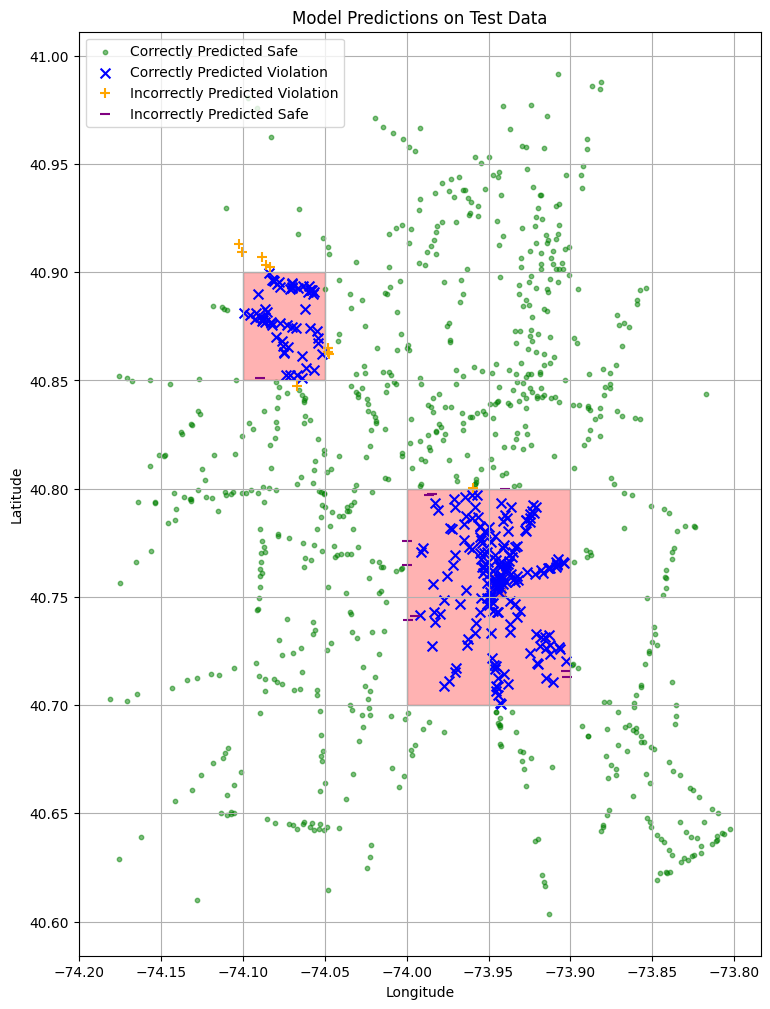

In [14]:
print("\nStep 10: Loading model and visualising test results...")

# --- Load the Model ---
loaded_model = ViolationDetector(input_features=input_dim)
loaded_model.load_state_dict(torch.load(MODEL_PATH))
loaded_model.to(device)
loaded_model.eval()
print("Model loaded successfully.")

# --- Make predictions (already done in step 8, but repeating for clarity) ---
with torch.no_grad():
    X_test_tensor_dev = X_test_tensor.to(device)
    predictions_probs = loaded_model(X_test_tensor_dev).cpu()
    predictions = (predictions_probs > 0.5).int().numpy().flatten()

# --- Visualize Output ---
# We need to un-scale the test data to plot it correctly
X_test_unscaled = scaler.inverse_transform(X_test)
test_results_df = pd.DataFrame(X_test_unscaled, columns=['longitude', 'latitude'])
test_results_df['true_label'] = y_true
test_results_df['predicted_label'] = predictions

# Plotting
fig, ax = plt.subplots(1, 1, figsize=(12, 12))
zones_gdf.plot(ax=ax, color='red', alpha=0.3, edgecolor='black', label='Restricted Zones')

# True Negatives (Correctly predicted as safe)
tn_df = test_results_df[(test_results_df['true_label'] == 0) & (test_results_df['predicted_label'] == 0)]
ax.scatter(tn_df['longitude'], tn_df['latitude'], color='green', label='Correctly Predicted Safe', s=10, alpha=0.5)

# True Positives (Correctly predicted as violation)
tp_df = test_results_df[(test_results_df['true_label'] == 1) & (test_results_df['predicted_label'] == 1)]
ax.scatter(tp_df['longitude'], tp_df['latitude'], color='blue', label='Correctly Predicted Violation', s=50, marker='x')

# False Positives (Incorrectly predicted as violation)
fp_df = test_results_df[(test_results_df['true_label'] == 0) & (test_results_df['predicted_label'] == 1)]
ax.scatter(fp_df['longitude'], fp_df['latitude'], color='orange', label='Incorrectly Predicted Violation', s=50, marker='+')

# False Negatives (Incorrectly predicted as safe)
fn_df = test_results_df[(test_results_df['true_label'] == 1) & (test_results_df['predicted_label'] == 0)]
ax.scatter(fn_df['longitude'], fn_df['latitude'], color='purple', label='Incorrectly Predicted Safe', s=50, marker='_')


ax.set_title('Model Predictions on Test Data')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.legend()
plt.grid(True)
plt.savefig("test_results_visualization.png")
print("Saved test results visualization to test_results_visualization.png")
plt.show()